# Random Forest Classification



Ky notebook trajnon dhe vlereson nje model Random Forest per klasifikimin e cmimeve ne klasa.

## 1. Importimi i librarive dhe ngarkimi i dataset-it

In [1]:
from pathlib import Path



import matplotlib.pyplot as plt

import pandas as pd

from sklearn.ensemble import RandomForestClassifier

from sklearn.base import clone

from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

import seaborn as sns

from sklearn.tree import plot_tree



RANDOM_STATE = 42



# Gjejme folderin kryesor te projektit, pavaresisht nga ku hapet notebook-u.

project_root = Path.cwd()

while not (project_root / "data" / "processed").exists() and project_root != project_root.parent:

    project_root = project_root.parent



data_dir = project_root / "data" / "processed"

# Per Random Forest perdorim dataset-et unscaled, sepse modelet me peme nuk kane nevoje per scaling.

train_path = data_dir / "train_unscaled_dataset.csv"

val_path = data_dir / "val_unscaled_dataset.csv"

test_path = data_dir / "test_unscaled_dataset.csv"



train_df = pd.read_csv(train_path)

val_df = pd.read_csv(val_path)

test_df = pd.read_csv(test_path)



print("Train dataset:", train_path)

print("Validation dataset:", val_path)

print("Test dataset:", test_path)

Train dataset: c:\Users\PC\House-Price-Prediction-Machine-Learning-Models\data\processed\train_unscaled_dataset.csv
Validation dataset: c:\Users\PC\House-Price-Prediction-Machine-Learning-Models\data\processed\val_unscaled_dataset.csv
Test dataset: c:\Users\PC\House-Price-Prediction-Machine-Learning-Models\data\processed\test_unscaled_dataset.csv


### Interpretim: pse perdorim dataset-et unscaled

Random Forest bazohet ne ndarje te tipit `feature <= threshold`, jo ne distanca mes pikave. Prandaj shkallezimi nuk eshte i domosdoshem si te KNN ose Logistic Regression. Dataset-et `train_unscaled_dataset.csv`, `val_unscaled_dataset.csv` dhe `test_unscaled_dataset.csv` jane te pershtatshme sepse ruajne vlerat origjinale te features dhe modeli me peme nuk ndikohet nga ndryshimi i shkalles se kolonave.

## 2. Kontroll i shkurter i te dhenave

In [2]:
print("Train shape:", train_df.shape)

print("Validation shape:", val_df.shape)

print("Test shape:", test_df.shape)



display(train_df.head())

print("\nMissing values:")

print("Train:", train_df.isna().sum().sum())

print("Validation:", val_df.isna().sum().sum())

print("Test:", test_df.isna().sum().sum())



print("\nData types:")

print(train_df.dtypes.value_counts())

Train shape: (12810, 53)
Validation shape: (4267, 53)
Test shape: (4279, 53)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,is_luxury_grade,is_high_view,is_premium,waterfront_grade,waterfront_sqft_living,view_grade,view_sqft_living,grade_lat_bin,grade_location_cluster,price_class
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,...,0,0,0,0,0,0,0,35,42,Low
1,3,2.25,1715,6819,2.0,0,0,3,7,1715,...,0,0,0,0,0,0,0,14,49,Low
2,3,1.00,1780,7470,1.0,0,0,3,7,1050,...,0,0,0,0,0,0,0,35,7,Low
3,3,2.50,3560,9796,1.0,0,0,3,8,1860,...,0,0,0,0,0,0,0,56,152,High
4,2,1.00,1160,6000,1.0,0,0,4,7,860,...,0,0,0,0,0,0,0,56,21,Medium



Missing values:
Train: 0
Validation: 0
Test: 0

Data types:
int64      35
float64    17
str         1
Name: count, dtype: int64


## 3. Ndarja e features dhe target-it

In [3]:
target_col = "price_class"



feature_cols = [col for col in train_df.columns if col != target_col]



X_train = train_df[feature_cols].copy()

y_train = train_df[target_col]



X_val = val_df[feature_cols].copy()

y_val = val_df[target_col]



X_test = test_df[feature_cols].copy()

y_test = test_df[target_col]

## 4. Defino funksionin evaluate_model

In [4]:
def evaluate_model(model, X, y, model_name):

    y_pred = model.predict(X)



    results = {

        "Model": model_name,

        "Accuracy": accuracy_score(y, y_pred),

        "Precision Macro": precision_score(y, y_pred, average="macro", zero_division=0),

        "Recall Macro": recall_score(y, y_pred, average="macro", zero_division=0),

        "F1 Macro": f1_score(y, y_pred, average="macro", zero_division=0),

    }



    print(model_name)

    print("Accuracy:", round(results["Accuracy"], 4))

    print("Precision Macro:", round(results["Precision Macro"], 4))

    print("Recall Macro:", round(results["Recall Macro"], 4))

    print("F1 Macro:", round(results["F1 Macro"], 4))



    print("\nClassification report:")

    print(classification_report(y, y_pred, zero_division=0))



    return results, y_pred

## 5. Baseline dhe krahasimi i konfigurimeve Random Forest ne validation



Fillimisht trajnojme nje model baseline me parametrat default te `RandomForestClassifier`, duke vendosur vetem `random_state=42` dhe `n_jobs=-1`. Ky model sherben si pike reference per konfigurimet e tjera.

In [5]:
rf_models = {
    "RF - Baseline": RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "RF - Gini": RandomForestClassifier(
        n_estimators=100,
        criterion="gini",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "RF - Entropy": RandomForestClassifier(
        n_estimators=100,
        criterion="entropy",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "RF - Max Depth 10": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "RF - Gini Regularized": RandomForestClassifier(
        n_estimators=200,
        criterion="gini",
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "RF - Entropy Regularized": RandomForestClassifier(
        n_estimators=200,
        criterion="entropy",
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=4,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
}

validation_results = []

for name, model in rf_models.items():
    model.fit(X_train, y_train)
    results, _ = evaluate_model(model, X_val, y_val, name)
    validation_results.append(results)

validation_results_df = pd.DataFrame(validation_results).sort_values("F1 Macro", ascending=False)
display(validation_results_df)

# Hyperparameter tuning me RandomizedSearchCV
param_distributions = {
    "n_estimators": [200, 300, 500],
    "max_depth": [10, 15, 20, 25],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf": [2, 4, 6, 8],
    "max_features": ["sqrt", "log2"],
    "criterion": ["gini", "entropy"],
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=30,
    scoring="f1_macro",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train)

print("Best RandomizedSearchCV params:")
print(rf_search.best_params_)
print("Best CV F1 Macro:", round(rf_search.best_score_, 4))

rf_search_results = pd.DataFrame(rf_search.cv_results_).sort_values("rank_test_score")
top_10_tuning_results = rf_search_results[[
    "params",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]].head(10)

display(top_10_tuning_results)

tuned_rf = rf_search.best_estimator_
tuned_results, _ = evaluate_model(tuned_rf, X_val, y_val, "RF - Tuned RandomizedSearchCV")

validation_results_df = pd.concat(
    [validation_results_df, pd.DataFrame([tuned_results])],
    ignore_index=True
).sort_values("F1 Macro", ascending=False)

display(validation_results_df)

best_model_name = validation_results_df.iloc[0]["Model"]
best_rf = tuned_rf if best_model_name == "RF - Tuned RandomizedSearchCV" else rf_models[best_model_name]

print("Best model based on validation F1 Macro:", best_model_name)

RF - Baseline
Accuracy: 0.8406
Precision Macro: 0.841
Recall Macro: 0.8399
F1 Macro: 0.8404

Classification report:
              precision    recall  f1-score   support

        High       0.88      0.87      0.88      1435
         Low       0.89      0.88      0.88      1442
      Medium       0.75      0.78      0.76      1390

    accuracy                           0.84      4267
   macro avg       0.84      0.84      0.84      4267
weighted avg       0.84      0.84      0.84      4267

RF - Gini
Accuracy: 0.8406
Precision Macro: 0.841
Recall Macro: 0.8399
F1 Macro: 0.8404

Classification report:
              precision    recall  f1-score   support

        High       0.88      0.87      0.88      1435
         Low       0.89      0.88      0.88      1442
      Medium       0.75      0.78      0.76      1390

    accuracy                           0.84      4267
   macro avg       0.84      0.84      0.84      4267
weighted avg       0.84      0.84      0.84      4267

RF - Entro

,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro
2,RF - Entropy,0.842044,0.842613,0.841322,0.841839
0,RF - Baseline,0.840637,0.841032,0.839897,0.840361
1,RF - Gini,0.840637,0.841032,0.839897,0.840361
4,RF - Gini Regularized,0.838997,0.840386,0.838337,0.839086
5,RF - Entropy Regularized,0.838294,0.839115,0.837588,0.838181
3,RF - Max Depth 10,0.835013,0.838071,0.834517,0.835662


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best RandomizedSearchCV params:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 15, 'criterion': 'gini'}
Best CV F1 Macro: 0.8315


,params,mean_test_score,std_test_score,rank_test_score
29,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.831453,0.006219,1
10,"{'n_estimators': 500, 'min_samples_split': 5, ...",0.830393,0.007422,2
16,"{'n_estimators': 300, 'min_samples_split': 10,...",0.830070,0.005756,3
23,"{'n_estimators': 200, 'min_samples_split': 10,...",0.829083,0.006255,4
24,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.828714,0.005915,5
19,"{'n_estimators': 200, 'min_samples_split': 5, ...",0.828168,0.006433,6
5,"{'n_estimators': 300, 'min_samples_split': 10,...",0.828108,0.006714,7
22,"{'n_estimators': 200, 'min_samples_split': 5, ...",0.827271,0.008532,8
8,"{'n_estimators': 300, 'min_samples_split': 5, ...",0.826873,0.006038,9
18,"{'n_estimators': 500, 'min_samples_split': 5, ...",0.826232,0.006599,10


RF - Tuned RandomizedSearchCV
Accuracy: 0.8411
Precision Macro: 0.8424
Recall Macro: 0.8404
F1 Macro: 0.8411

Classification report:
              precision    recall  f1-score   support

        High       0.89      0.86      0.87      1435
         Low       0.89      0.88      0.88      1442
      Medium       0.75      0.78      0.77      1390

    accuracy                           0.84      4267
   macro avg       0.84      0.84      0.84      4267
weighted avg       0.84      0.84      0.84      4267



,Model,Accuracy,Precision Macro,Recall Macro,F1 Macro
0,RF - Entropy,0.842044,0.842613,0.841322,0.841839
6,RF - Tuned RandomizedSearchCV,0.841106,0.842366,0.840449,0.841136
1,RF - Baseline,0.840637,0.841032,0.839897,0.840361
2,RF - Gini,0.840637,0.841032,0.839897,0.840361
3,RF - Gini Regularized,0.838997,0.840386,0.838337,0.839086
4,RF - Entropy Regularized,0.838294,0.839115,0.837588,0.838181
5,RF - Max Depth 10,0.835013,0.838071,0.834517,0.835662


Best model based on validation F1 Macro: RF - Entropy


### Interpretim: parametrat me te mire

Tabela `top_10_tuning_results` tregon kombinimet me te mira te parametrave nga `RandomizedSearchCV`, te renditura sipas `mean_test_score`, ku metrika e perdorur eshte `f1_macro`. Kombinimi me renditje te pare arriti mean_test_score = 0.831453 dhe std_test_score = 0.006219, qe tregon performance relativisht stabile gjate cross-validation.

Nga top 10 rezultatet shihet se konfigurimet me performance me te mire zakonisht perdorin nje numer me te madh pemesh, sidomos `n_estimators` 200, 300 ose 500. Kjo tregon se rritja e numrit te pemeve ndihmon modelin te jete me stabil. Gjithashtu, disa nga rezultatet me te mira perdorin `min_samples_split` 5 ose 10, qe kufizon ndarjet shume te vogla dhe ndihmon ne uljen e overfitting.

Vlerat e `std_test_score` jane relativisht te vogla, rreth 0.006 deri 0.008, qe tregon se rezultatet ne fold-et e cross-validation nuk ndryshojne shume. Kjo eshte shenje e mire per stabilitetin e modelit te tunuar.

## 6. Krahasimi Train vs Validation dhe kontrolli per overfitting



Krahasojme performancen e modelit me te mire ne train dhe validation set. Nese metrikat ne train jane shume me te larta se ne validation, kjo tregon shenja te overfitting. Nese vlerat jane te aferta, modeli gjeneralizon me mire.

In [6]:
candidate_models = {
    "RF - Entropy": rf_models["RF - Entropy"],
    "RF - Tuned RandomizedSearchCV": tuned_rf,
    "RF - Gini Regularized": rf_models["RF - Gini Regularized"],
    "RF - Entropy Regularized": rf_models["RF - Entropy Regularized"],
}

overfitting_results = []

for name, model in candidate_models.items():
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_f1 = f1_score(y_train, train_pred, average="macro", zero_division=0)
    val_f1 = f1_score(y_val, val_pred, average="macro", zero_division=0)

    overfitting_results.append({
        "Model": name,
        "Train F1 Macro": train_f1,
        "Validation F1 Macro": val_f1,
        "F1 Gap": train_f1 - val_f1,
        "Validation Accuracy": accuracy_score(y_val, val_pred),
        "Validation Precision Macro": precision_score(y_val, val_pred, average="macro", zero_division=0),
        "Validation Recall Macro": recall_score(y_val, val_pred, average="macro", zero_division=0),
    })

overfitting_results_df = pd.DataFrame(overfitting_results).sort_values(
    ["Validation F1 Macro", "F1 Gap"],
    ascending=[False, True]
)

display(overfitting_results_df)

,Model,Train F1 Macro,Validation F1 Macro,F1 Gap,Validation Accuracy,Validation Precision Macro,Validation Recall Macro
0,RF - Entropy,1.000000,0.841839,0.158161,0.842044,0.842613,0.841322
1,RF - Tuned RandomizedSearchCV,0.965519,0.841136,0.124383,0.841106,0.842366,0.840449
2,RF - Gini Regularized,0.940061,0.839086,0.100975,0.838997,0.840386,0.838337
3,RF - Entropy Regularized,0.945832,0.838181,0.107651,0.838294,0.839115,0.837588


### Interpretim: overfitting

Nga krahasimi train vs validation shihet se `RF - Entropy` ka performancën më të lartë në validation set, por ka edhe shenja të qarta overfitting, sepse arrin Train F1 Macro = 1.0000 dhe gap train-validation = 0.1582. Kjo tregon se modeli ka mësuar shumë mirë train set-in, por nuk gjeneralizon po aq mirë në validation.

`RF - Tuned RandomizedSearchCV` ul overfitting-un krahasuar me `RF - Entropy`, por ende ka gap train-validation = 0.1244. Ndërsa `RF - Gini Regularized` ka Validation F1 Macro = 0.8391, vetëm rreth 0.002 më të ulët se modeli i tunuar, por ka gap më të vogël train-validation = 0.1010.

Për këtë arsye, zgjedhja finale është `RF - Gini Regularized`. Edhe pse humb shumë pak në validation F1 Macro, ai është model më i balancuar dhe më pak i prirur ndaj overfitting. Parametrat regularizues si `max_depth`, `min_samples_split`, `min_samples_leaf` dhe `max_features="sqrt"` kufizojnë kompleksitetin e pemëve dhe ndihmojnë modelin të gjeneralizojë më mirë në të dhëna të reja.

## 7. Testimi final ne test set

In [7]:
best_model_name = "RF - Gini Regularized"
best_rf = rf_models[best_model_name]

In [8]:
X_train_final = pd.concat([X_train, X_val], ignore_index=True)

y_train_final = pd.concat([y_train, y_val], ignore_index=True)



final_rf = clone(best_rf)

final_rf.fit(X_train_final, y_train_final)



print("Final model:", best_model_name)

print("Final training samples:", X_train_final.shape[0])



test_results, test_pred = evaluate_model(

    final_rf,

    X_test,

    y_test,

    f"{best_model_name} - Final Test"

)

Final model: RF - Gini Regularized
Final training samples: 17077
RF - Gini Regularized - Final Test
Accuracy: 0.846
Precision Macro: 0.8477
Recall Macro: 0.8459
F1 Macro: 0.8465

Classification report:
              precision    recall  f1-score   support

        High       0.88      0.88      0.88      1406
         Low       0.91      0.86      0.88      1461
      Medium       0.76      0.79      0.78      1412

    accuracy                           0.85      4279
   macro avg       0.85      0.85      0.85      4279
weighted avg       0.85      0.85      0.85      4279



### Interpretim: performanca ne test

Rezultatet e test set-it jane vleresimi final i modelit, sepse test set nuk eshte perdorur per zgjedhjen e parametrave. `Accuracy` tregon saktesine totale, ndersa `F1 Macro` eshte metrika kryesore sepse jep peshe te barabarte per secilen klase. Nese `F1 Macro` ne test eshte afer vleres ne validation, modeli gjeneralizon mire. Nese bie ndjeshem, modeli mund te jete pershtatur me validation gjate zgjedhjes se parametrave.

Modeli final `RF - Gini Regularized`, i trajnuar me train + validation, arriti Accuracy = 0.8460 dhe F1 Macro = 0.8465 ne test set. Kjo eshte pak me e larte se performanca e tij ne validation set (F1 Macro = 0.8391), qe tregon se modeli gjeneralizon mire ne te dhena te papara. Zgjedhja e modelit te rregulluar rezultoi e arsyeshme, sepse ai kishte me pak overfitting sesa `RF - Entropy` dhe performoi mire ne test final.

## 8. Vizualizimi i nje peme nga modeli final

Random Forest perbehet nga shume peme vendimi. Per interpretim vizualizohet vetem nje peme perfaqesuese nga modeli final i trajnuar me train + validation. Thellesia kufizohet ne `max_depth=3` qe grafiku te mbetet i lexueshem.

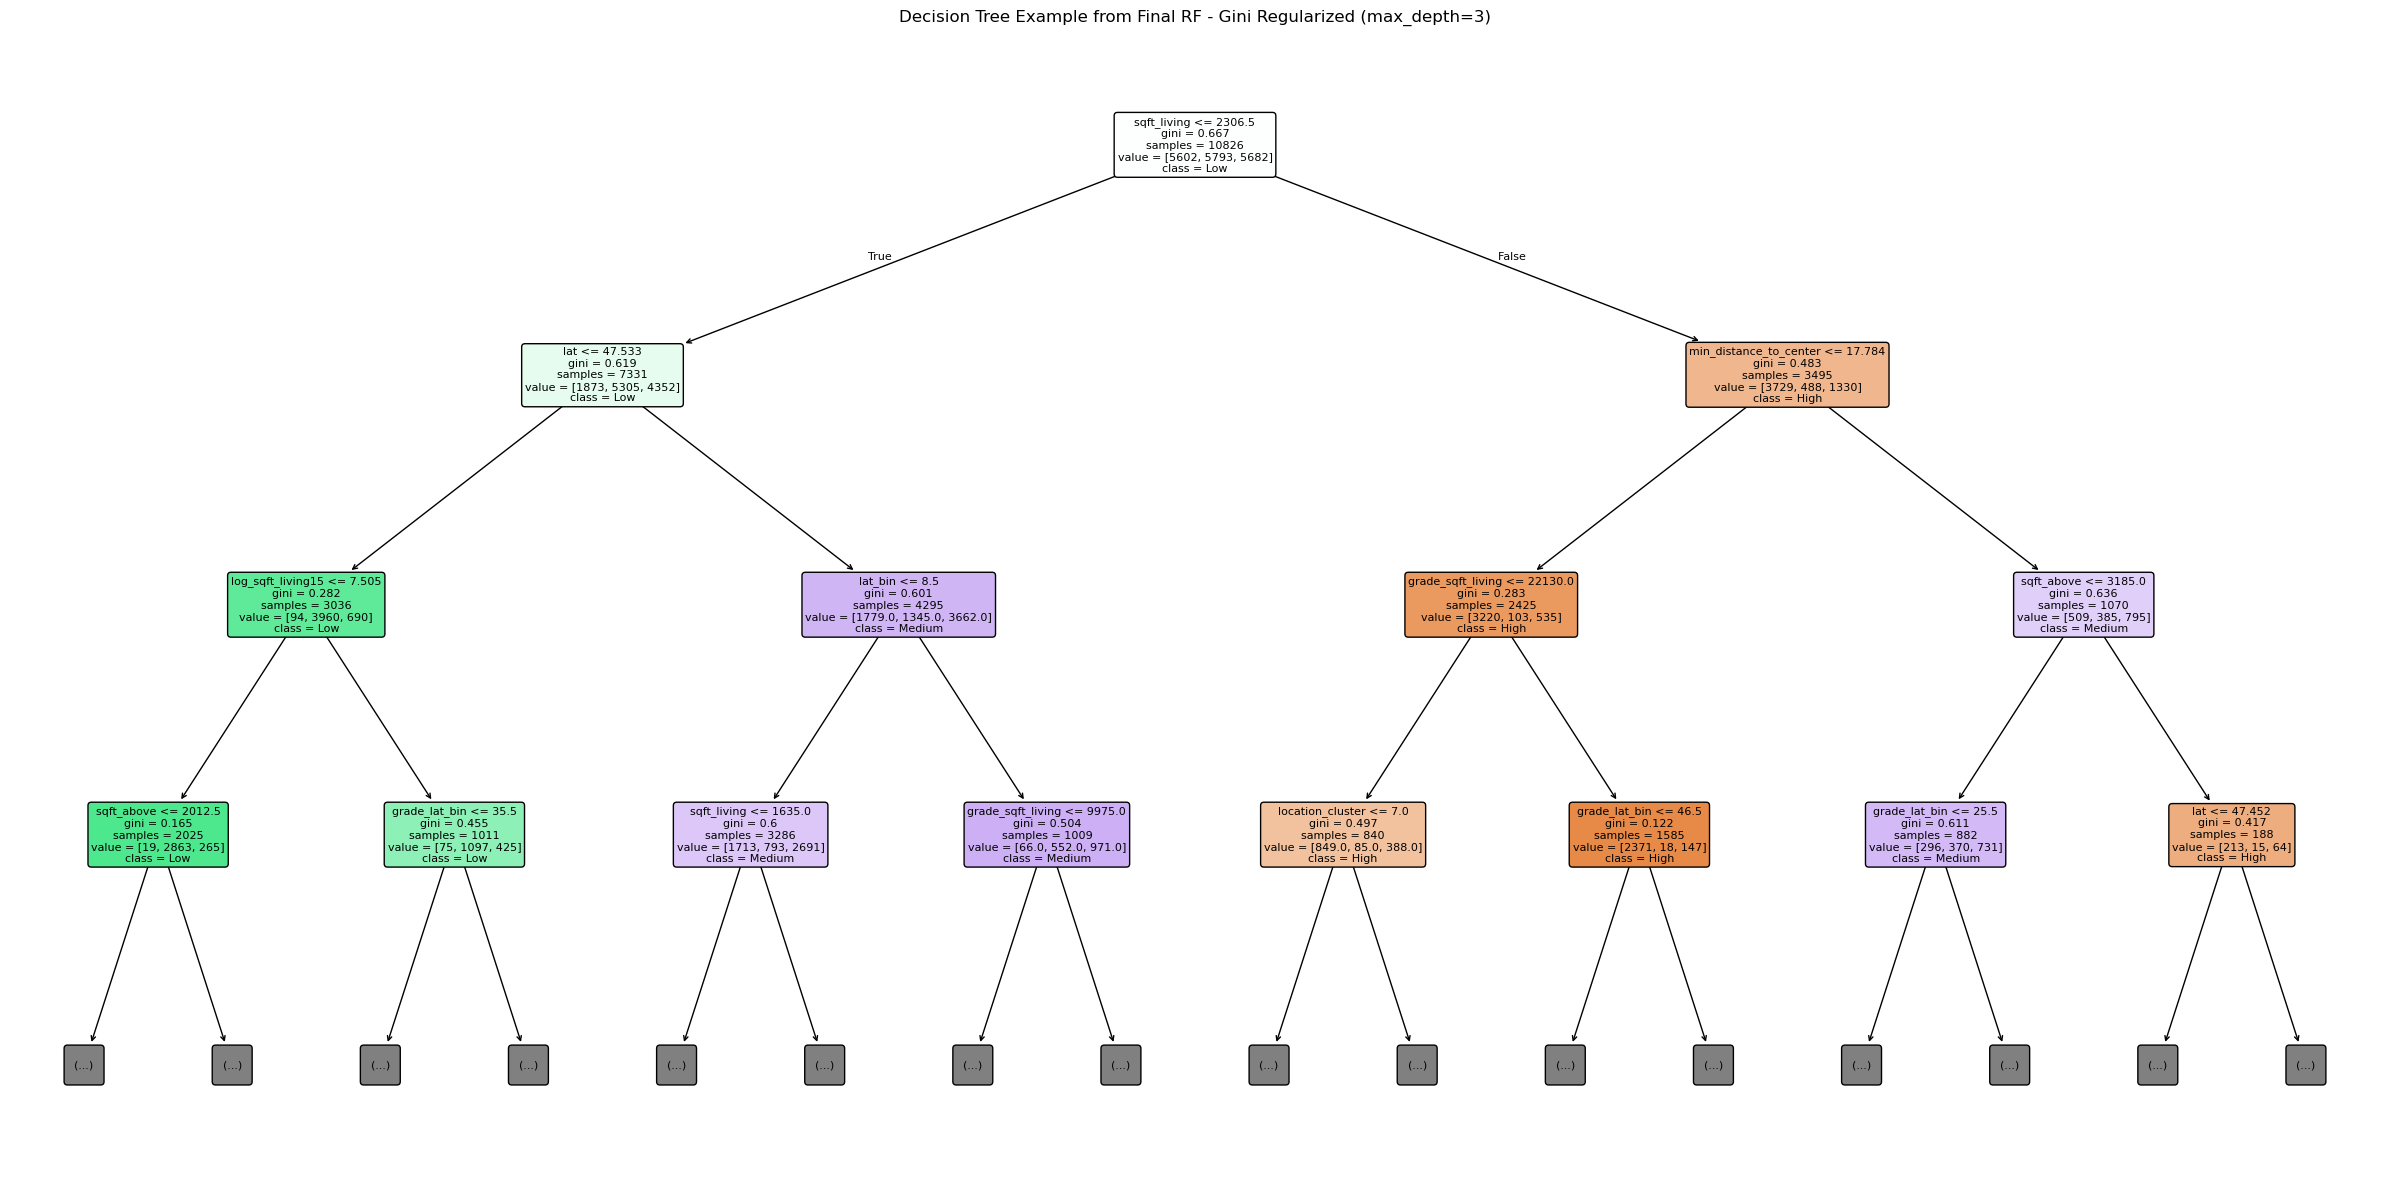

In [9]:
plt.figure(figsize=(24, 12))



plot_tree(

    final_rf.estimators_[0],

    feature_names=X_train.columns,

    class_names=[str(c) for c in final_rf.classes_],

    filled=True,

    rounded=True,

    max_depth=3,

    fontsize=8,

)



plt.title(f"Decision Tree Example from Final {best_model_name} (max_depth=3)")

plt.tight_layout()

plt.show()

## 9. Confusion Matrix per test

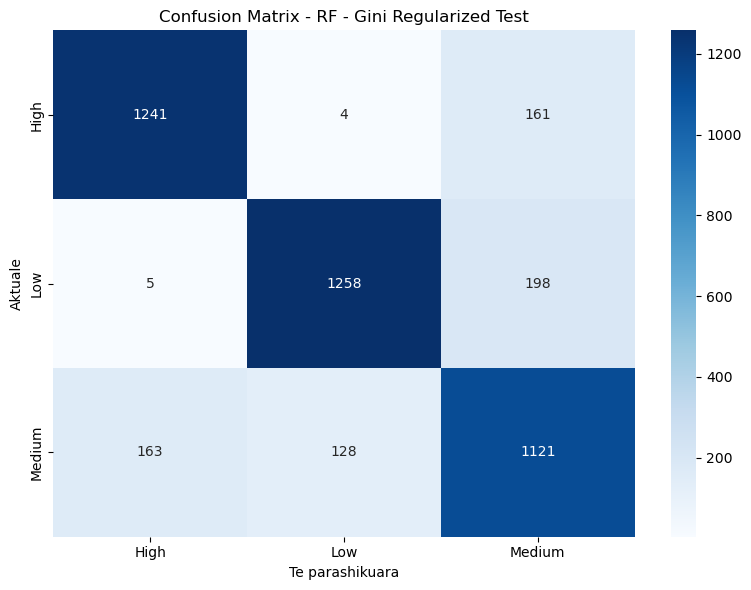

In [10]:
labels = final_rf.classes_



plt.figure(figsize=(8, 6))

sns.heatmap(

    confusion_matrix(y_test, test_pred, labels=labels),

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=labels,

    yticklabels=labels

)

plt.title(f"Confusion Matrix - {best_model_name} Test")

plt.ylabel("Aktuale")

plt.xlabel("Te parashikuara")

plt.tight_layout()

plt.show()

### Interpretim: confusion matrix

Confusion matrix tregon se modeli klasifikon mire klasat ekstreme `High` dhe `Low`, sepse shumica e rasteve jane ne diagonale: 1241 raste `High` jane parashikuar sakte si `High`, dhe 1258 raste `Low` jane parashikuar sakte si `Low`.

Gabimet kryesore ndodhin te klasa `Medium`. Modeli parashikon 198 raste `Low` si `Medium`, 163 raste `Medium` si `High`, 161 raste `High` si `Medium`, dhe 128 raste `Medium` si `Low`. Kjo tregon se klasa `Medium` ka mbivendosje me dy klasat e tjera dhe eshte me e veshtira per t'u ndare qarte.

Gabimet direkte mes klasave ekstreme jane shume te vogla: vetem 4 raste `High` jane parashikuar si `Low`, dhe vetem 5 raste `Low` jane parashikuar si `High`. Kjo eshte shenje e mire, sepse modeli rrallë ngaterron cmimet shume te larta me cmimet shume te ulëta.

## 10. Feature Importance

Random Forest mundeson analizen e rendesise se features. Kjo tregon cilat karakteristika kane kontribuar me shume ne ndarjen e klasave te cmimit.

,Feature,Importance
50,grade_lat_bin,0.099469
14,lat,0.095601
34,grade_sqft_living,0.082308
40,lat_bin,0.060905
24,log_sqft_living,0.058334
2,sqft_living,0.057093
36,lat_long,0.042135
39,min_distance_to_center,0.041798
26,log_sqft_living15,0.038585
8,grade,0.037174


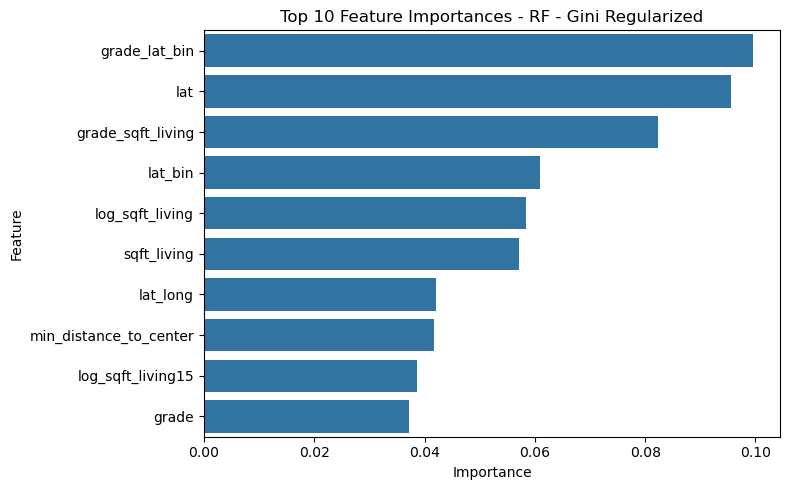

In [11]:
feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": final_rf.feature_importances_

}).sort_values("Importance", ascending=False)



display(feature_importance.head(10))



plt.figure(figsize=(8, 5))

sns.barplot(

    data=feature_importance.head(10),

    x="Importance",

    y="Feature"

)

plt.title(f"Top 10 Feature Importances - {best_model_name}")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.tight_layout()

plt.show()

### Interpretim: feature importance

Grafiku `Top 10 Feature Importances` tregon se karakteristikat me ndikimin me te madh ne model jane kryesisht te lidhura me lokacionin, madhesine e baneses dhe cilesine e saj.

Feature me rendesine me te larte eshte `grade_lat_bin`, qe kombinon cilesine e shtepise (`grade`) me pozicionin gjeografik (`lat_bin`). Kjo tregon se modeli e konsideron shume te rendesishem kombinimin mes cilesise se prones dhe lokacionit. Edhe `lat`, `lat_bin`, `lat_long` dhe `min_distance_to_center` jane nder features me te rendesishme, qe konfirmon se lokacioni ka rol te madh ne klasifikimin e cmimit.

Features si `grade_sqft_living`, `log_sqft_living`, `sqft_living`, `log_sqft_living15` dhe `grade` tregojne se madhesia e baneses dhe cilesia e saj jane po ashtu faktore kryesore per ndarjen e klasave `Low`, `Medium` dhe `High`.

Keto rezultate jane logjike per problemin e cmimeve te shtepive: pronat me lokacion me te mire, grade me te larte dhe hapesire me te madhe kane me shume gjasa te klasifikohen ne klasa me te larta cmimi. Megjithate, feature importance tregon rendesi relative brenda modelit dhe nuk duhet interpretuar si shkakesi direkte.

## 11. Ruajtja e rezultateve

Ruajme metrikat finale, rezultatet e validation, feature importance, confusion matrix, classification report dhe rezultatet e hyperparameter tuning per krahasim dhe raportim te metejshem.

In [12]:
results_dir = data_dir / "model_results"

results_dir.mkdir(parents=True, exist_ok=True)



pd.DataFrame([test_results]).to_csv(results_dir / "random_forest_results.csv", index=False)

validation_results_df.to_csv(results_dir / "random_forest_validation_results.csv", index=False)

feature_importance.to_csv(results_dir / "random_forest_feature_importance.csv", index=False)



confusion_matrix_df = pd.DataFrame(

    confusion_matrix(y_test, test_pred, labels=labels),

    index=[f"true_{label}" for label in labels],

    columns=[f"pred_{label}" for label in labels],

)

confusion_matrix_df.to_csv(results_dir / "random_forest_confusion_matrix.csv")



classification_report_df = pd.DataFrame(

    classification_report(y_test, test_pred, output_dict=True, zero_division=0)

).transpose()

classification_report_df.to_csv(results_dir / "random_forest_classification_report.csv")



rf_search_results[[

    "params",

    "mean_test_score",

    "std_test_score",

    "rank_test_score",

]].to_csv(results_dir / "random_forest_grid_search_results.csv", index=False)



print("Rezultatet u ruajten ne:", results_dir)

print("- random_forest_results.csv")

print("- random_forest_validation_results.csv")

print("- random_forest_feature_importance.csv")

print("- random_forest_confusion_matrix.csv")

print("- random_forest_classification_report.csv")

print("- random_forest_grid_search_results.csv")

Rezultatet u ruajten ne: c:\Users\PC\House-Price-Prediction-Machine-Learning-Models\data\processed\model_results
- random_forest_results.csv
- random_forest_validation_results.csv
- random_forest_feature_importance.csv
- random_forest_confusion_matrix.csv
- random_forest_classification_report.csv
- random_forest_grid_search_results.csv


## 12. Kufizime dhe perfundim

Random Forest rezultoi model i forte per kete dataset, sepse arriti performance te mire ne klasifikimin e cmimeve te shtepive. Modeli final i zgjedhur ishte `RF - Gini Regularized`, sepse ofroi balancen me te mire mes performances dhe kontrollit te overfitting. Edhe pse `RF - Entropy` kishte F1 Macro me te larte ne validation, ai arriti Train F1 Macro = 1.0000 dhe gap train-validation = 0.1582, qe tregon overfitting te dukshem. `RF - Gini Regularized` kishte validation F1 Macro pak me te ulet, por gap me te vogel, prandaj u zgjodh si model me stabil.

Ne test set, modeli final `RF - Gini Regularized`, i trajnuar me train + validation, arriti Accuracy = 0.8460 dhe F1 Macro = 0.8465. Kjo performance eshte pak me e larte se performanca e tij ne validation set dhe tregon se modeli gjeneralizon mire ne te dhena te papara. Per kete arsye, Random Forest mund te konsiderohet model i pershtatshem per kete problem klasifikimi.

Nga confusion matrix u pa se modeli klasifikon mire klasat ekstreme `High` dhe `Low`. Gabimet direkte mes tyre jane shume te vogla: vetem 4 raste `High` u klasifikuan si `Low`, dhe vetem 5 raste `Low` u klasifikuan si `High`. Gabimet kryesore ndodhin te klasa `Medium`, e cila ngaterrohet me te dyja klasat e tjera. Kjo eshte e pritshme, sepse `Medium` eshte klase ndermjetese dhe kufijte e cmimit mund te mbivendosen.

Feature importance tregoi se modeli mbeshtetet kryesisht ne lokacion, madhesine e baneses dhe cilesine e saj. Features si `grade_lat_bin`, `lat`, `grade_sqft_living`, `lat_bin`, `log_sqft_living`, `sqft_living`, `lat_long`, `min_distance_to_center` dhe `grade` ishin nder me te rendesishmet. Kjo eshte logjike per cmimet e shtepive, sepse lokacioni, hapesira dhe cilesia jane faktore kryesore ne percaktimin e vleres se prones.

Megjithate, modeli ka disa kufizime. Random Forest eshte me interpretueshem se disa modele te tjera, por nuk eshte plotesisht transparent sepse vendimi final vjen nga kombinimi i shume pemeve. Po ashtu, feature importance tregon rendesi relative brenda modelit, jo shkakesi direkte. Nje feature me rendesi te larte nuk do te thote domosdoshmerisht qe shkakton rritje ose ulje te cmimit. Gjithashtu, Random Forest mund te overfit-oje nese pemet jane shume te thella ose nese mungojne kufizime si `max_depth`, `min_samples_leaf` dhe `min_samples_split`.